# 🏀 NBA Shot Analysis

---

## 1. Load required libraries

In [1]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    roc_curve, auc, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    accuracy_score
)
from sklearn.calibration import calibration_curve

sns.set_theme(style='whitegrid')

/Users/mykolapoliakov/PycharmProjects/nba_shot_predictions/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Load Data

In [2]:
ds = load_dataset(
    'ds-training-nba/nba_shot_data',
    data_files={'full': 'processed/processed_20_players.parquet'}
)
df = ds['full'].to_pandas()
print(df.info())
df.head(3)

Repo card metadata block was not found. Setting CardData to empty.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537909 entries, 0 to 537908
Data columns (total 54 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   GAME_ID_x                  537909 non-null  float64
 1   GAME_EVENT_ID              537909 non-null  float64
 2   SHOT_TYPE                  537909 non-null  object 
 3   SHOT_DISTANCE              537909 non-null  float64
 4   SHOT_ZONE_RANGE            537909 non-null  object 
 5   SHOT_ZONE_BASIC            537909 non-null  object 
 6   SHOT_ZONE_AREA             537909 non-null  object 
 7   LOC_X                      537909 non-null  float64
 8   LOC_Y                      537909 non-null  float64
 9   ACTION_TYPE                537909 non-null  object 
 10  HTM                        537909 non-null  object 
 11  VTM                        537909 non-null  object 
 12  GAME_DATE                  537909 non-null  float64
 13  TEAM_ID                    53

,GAME_ID_x,GAME_EVENT_ID,SHOT_TYPE,SHOT_DISTANCE,SHOT_ZONE_RANGE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,LOC_X,LOC_Y,ACTION_TYPE,...,OvertimeNumber,IsClutchTime,OPPONENT_INTERFERED,ANGLE,ANGLE_SECTOR,ABS_ANGLE,ANGLE_SIN,ANGLE_COS,MAIN_ACTION_TYPE,__index_level_0__
0,29600008.0,281.0,2PT Field Goal,8.0,8-16 ft.,In The Paint (Non-RA),Left Side(L),-42.0,69.0,Jump Shot,...,0,0,False,-31.328693,0,31.328693,0.087123,0.996198,Jump,448756
1,29600008.0,168.0,1PT Free Throw,15.0,8-16 ft.,Mid-Range,Center(C),0.0,15.0,Free Throw,...,0,0,False,0.000000,0,0.000000,0.000000,1.000000,Other,448749
2,29600008.0,404.0,2PT Field Goal,12.0,8-16 ft.,Mid-Range,Right Side(R),112.0,58.0,Jump Shot,...,0,1,False,62.622297,1,62.622297,-0.208025,0.978123,Jump,448762


## 3. 🔍 Data Leakage Analysis

In [3]:
# ── checking correlation with target field ─
target = 'SHOT_MADE_FLAG'

corr_with_target = df.corr(numeric_only=True)[target].drop(target)

corr_df = corr_with_target.reset_index()
corr_df.columns = ['Feature', 'Correlation with SHOT_MADE_FLAG']

corr_df['Leakage Risk'] = corr_df[
    'Correlation with SHOT_MADE_FLAG'
].abs().apply(
    lambda x:
        '🔴 HIGH — likely leakage' if x > 0.3 else
        ('🟡 MEDIUM — check carefully' if x > 0.1 else '🟢 LOW')
)

print(corr_df.to_string(index=False))

              Feature  Correlation with SHOT_MADE_FLAG               Leakage Risk
            GAME_ID_x                        -0.008077                      🟢 LOW
        GAME_EVENT_ID                         0.013756                      🟢 LOW
        SHOT_DISTANCE                        -0.141545 🟡 MEDIUM — check carefully
                LOC_X                         0.010066                      🟢 LOW
                LOC_Y                        -0.248657 🟡 MEDIUM — check carefully
            GAME_DATE                         0.006392                      🟢 LOW
              TEAM_ID                        -0.007429                      🟢 LOW
            PLAYER_ID                        -0.001959                      🟢 LOW
            scoreHome                         0.025600                      🟢 LOW
            scoreAway                         0.027700                      🟢 LOW
    MINUTES_REMAINING                        -0.025031                      🟢 LOW
    SECONDS_REMA

### Leakage type in current dataset:

| Column | Leakage type | Solving |
|---|---|---|
| `shotResult` | **Direct** — target field duplicate | ❌ Drop |
| `points` | **Direct** — adds AFTER throw | ❌ Drop |
| `pointsHome` / `pointsAway` | **Direct** — points AFTER throw | ❌ Drop |
| `scoreHome` / `scoreAway` | **Direct** — score AFTER throw | ❌ Drop |
| `scoreMargin` | **Direct** — points difference AFTER throw | ❌ Drop |
| `scoreMarginBeforeShot` | ✅ Safe | ✅ Leave |
| `scoreHomeBeforeShot` | ✅ Safe | ✅ Leave |
| `scoreAwayBeforeShot` | ✅ Safe | ✅ Leave |

## 4. Preprocessing

In [4]:
# ── Removing leakege and not necessary columnts ────────────────────
drop_cols = [
    # Directly leakage
    'points', 'pointsHome', 'pointsAway', 'scoreHome', 'scoreAway', 'scoreMargin', 'shotResult',
    # ID — don't make sense for the model
    '__index_level_0__', 'GAME_ID_x', 'GAME_EVENT_ID', 'PLAYER2_ID', 'PLAYER3_ID',
    # Duplicates
    'PCTIMESTRING', 'clock', 'SECONDS_REMAINING', 'GAME_DATE', 'MINUTES_REMAINING',
    # Abbreviations
    'PLAYER1_TEAM_ABBREVIATION', 'PLAYER2_TEAM_ABBREVIATION', 'PLAYER2_NAME', 'PLAYER3_NAME', 'VTM', 'HTM'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# ── Boolean ───────────────────────────────────────────────
for col in ['IS_HOME', 'IsClutchTime', 'IsOvertime']:
    if col in df.columns:
        df[col] = df[col].astype(bool)

print(f'Shape after cleanup: {df.shape}')
print(f'Remaining columns: {list(df.columns)}')

Shape after cleanup: (537909, 31)
Remaining columns: ['SHOT_TYPE', 'SHOT_DISTANCE', 'SHOT_ZONE_RANGE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'LOC_X', 'LOC_Y', 'ACTION_TYPE', 'TEAM_ID', 'PLAYER_ID', 'PLAYER_NAME', 'PERIOD_x', 'is_playoffs', 'SHOT_MADE_FLAG', 'IS_HOME', 'scoreHomeBeforeShot', 'scoreAwayBeforeShot', 'scoreMarginBeforeShot', 'TimeRemainingInPeriod', 'TotalPlayedTime', 'TimeRemainingInGame', 'IsOvertime', 'OvertimeNumber', 'IsClutchTime', 'OPPONENT_INTERFERED', 'ANGLE', 'ANGLE_SECTOR', 'ABS_ANGLE', 'ANGLE_SIN', 'ANGLE_COS', 'MAIN_ACTION_TYPE']


In [5]:
numerical_features = [
    'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
    'ANGLE_SIN', 'ANGLE_COS', 'ANGLE', 'ANGLE_SECTOR', 'ABS_ANGLE',
    'TimeRemainingInPeriod', 'TimeRemainingInGame',
    'scoreMarginBeforeShot', 'scoreHomeBeforeShot', 'scoreAwayBeforeShot',
    'PERIOD_x', 'OvertimeNumber', 'TEAM_ID', 'PLAYER_ID', 'TotalPlayedTime',
]
categorical_features = [
    'SHOT_TYPE', 'SHOT_ZONE_RANGE', 'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA', 'ACTION_TYPE', 'MAIN_ACTION_TYPE', 'PLAYER_NAME',
]
boolean_features = [
    'is_playoffs', 'IS_HOME', 'IsOvertime', 'IsClutchTime', 'OPPONENT_INTERFERED',
]

# Фильтруем только реально существующие
numerical_features  = [c for c in numerical_features  if c in df.columns]
categorical_features= [c for c in categorical_features if c in df.columns]
boolean_features    = [c for c in boolean_features    if c in df.columns]

all_features = numerical_features + boolean_features + categorical_features
target = 'SHOT_MADE_FLAG'

print('Numerical:', numerical_features)
print('Categorical:', categorical_features)
print('Boolean:', boolean_features)

Numerical: ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'ANGLE_SIN', 'ANGLE_COS', 'ANGLE', 'ANGLE_SECTOR', 'ABS_ANGLE', 'TimeRemainingInPeriod', 'TimeRemainingInGame', 'scoreMarginBeforeShot', 'scoreHomeBeforeShot', 'scoreAwayBeforeShot', 'PERIOD_x', 'OvertimeNumber', 'TEAM_ID', 'PLAYER_ID', 'TotalPlayedTime']
Categorical: ['SHOT_TYPE', 'SHOT_ZONE_RANGE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'ACTION_TYPE', 'MAIN_ACTION_TYPE', 'PLAYER_NAME']
Boolean: ['is_playoffs', 'IS_HOME', 'IsOvertime', 'IsClutchTime', 'OPPONENT_INTERFERED']


## 5. 📊 Feature Correlation Analysis

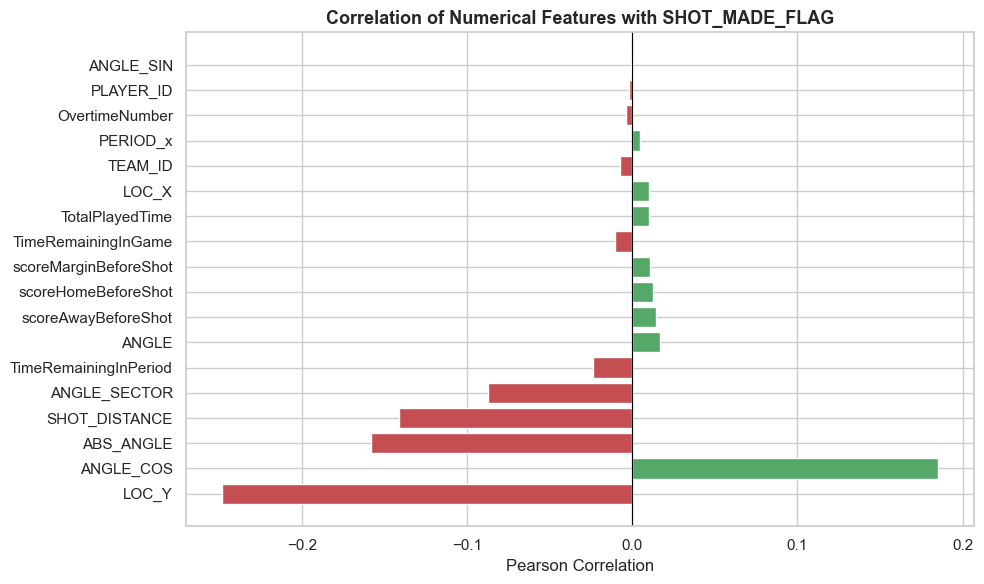

LOC_Y                   -0.248657
ANGLE_COS                0.185230
ABS_ANGLE               -0.158031
SHOT_DISTANCE           -0.141545
ANGLE_SECTOR            -0.087407
TimeRemainingInPeriod   -0.024070
ANGLE                    0.016684
scoreAwayBeforeShot      0.014013
scoreHomeBeforeShot      0.012653
scoreMarginBeforeShot    0.010597
TimeRemainingInGame     -0.010525
TotalPlayedTime          0.010297
LOC_X                    0.010066
TEAM_ID                 -0.007429
PERIOD_x                 0.004418
OvertimeNumber          -0.003584
PLAYER_ID               -0.001959
ANGLE_SIN               -0.000854
Name: SHOT_MADE_FLAG, dtype: float64


In [6]:
# ── Корреляция числовых признаков с таргетом ─────────────
corr_with_target = df[numerical_features + [target]].corr()[target].drop(target)
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['g' if v > 0 else 'r' for v in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Numerical Features with SHOT_MADE_FLAG', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(corr_with_target)

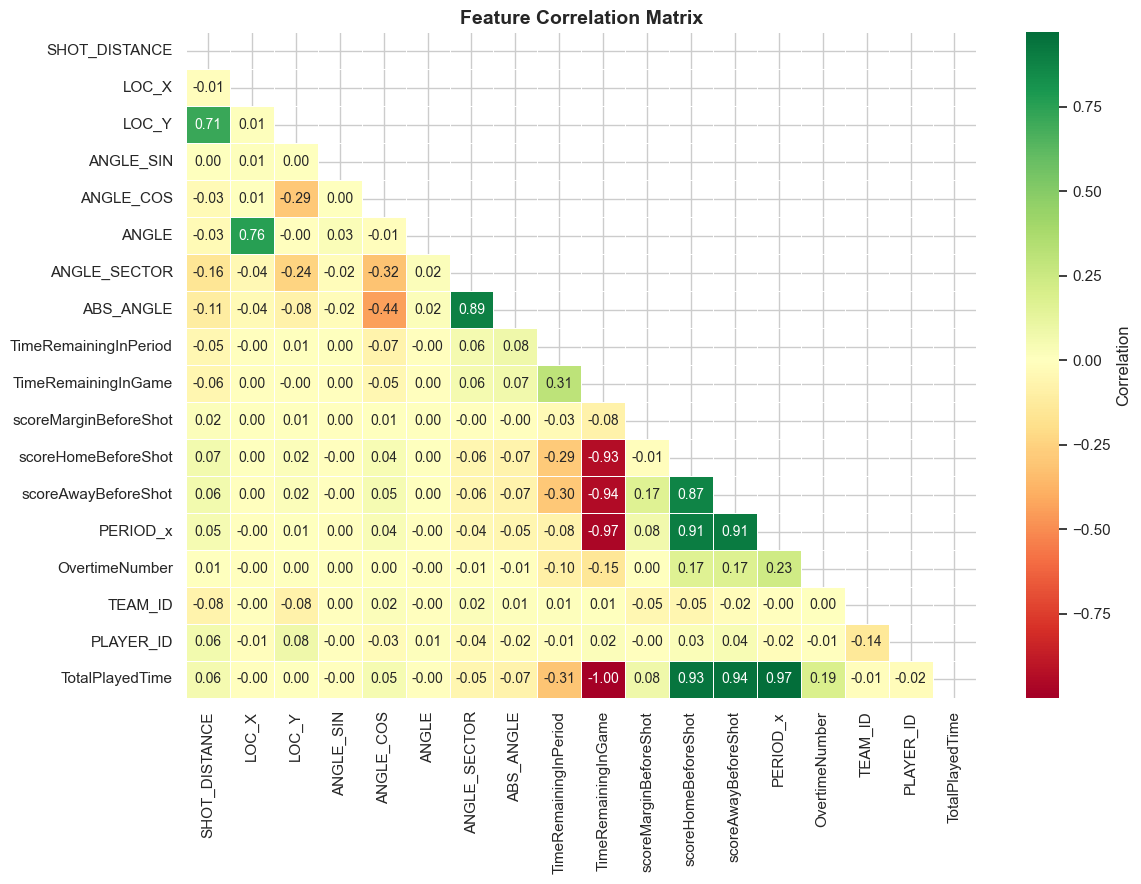

⚠️  Highly correlated pairs (|r| > 0.8) — consider removing one from each pair:
          Feature A           Feature B  Correlation
       ANGLE_SECTOR           ABS_ANGLE        0.890
TimeRemainingInGame scoreHomeBeforeShot       -0.934
TimeRemainingInGame scoreAwayBeforeShot       -0.939
TimeRemainingInGame            PERIOD_x       -0.967
TimeRemainingInGame     TotalPlayedTime       -0.999
scoreHomeBeforeShot scoreAwayBeforeShot        0.871
scoreHomeBeforeShot            PERIOD_x        0.906
scoreHomeBeforeShot     TotalPlayedTime        0.934
scoreAwayBeforeShot            PERIOD_x        0.910
scoreAwayBeforeShot     TotalPlayedTime        0.939
           PERIOD_x     TotalPlayedTime        0.970


In [7]:
# ── Correlation matrix of numerical features ─────────────
# Looking for multicollinearity (pairs of features with |corr| > 0.8)
corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Correlation'}, annot_kws={"size": 10}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Выводим пары с высокой корреляцией
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Correlation': round(val, 3)
            })

if high_corr_pairs:
    print('⚠️  Highly correlated pairs (|r| > 0.8) — consider removing one from each pair:')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('✅ No highly correlated feature pairs found.')

In [8]:
correlated_fields = ['TimeRemainingInGame', 'TotalPlayedTime', 'scoreAwayBeforeShot']

df = df.drop(columns=[c for c in correlated_fields if c in df.columns], errors='ignore')

all_features = [f for f in all_features if f not in correlated_fields]

## 6. Train/Test Split

In [9]:
df_model = df[all_features + [target]].dropna().sample(100000, random_state=42)

X = df_model[all_features]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'FG% train: {y_train.mean():.3f}  |  FG% test: {y_test.mean():.3f}')
print(f'Class balance OK: {abs(y_train.mean() - y_test.mean()) < 0.01}')

# ── Preprocessor ─────────────────────────────────────────
num_cols = X_train.select_dtypes(include=['int64','float64','int16','bool']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

Train: 80,000  |  Test: 20,000
FG% train: 0.570  |  FG% test: 0.570
Class balance OK: True


## 7. Baseline Models

We train 4 models: Logistic Regression, KNN, Random Forest, XGBoost.

In [10]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=1.0, max_iter=1000,
            class_weight='balanced', random_state=42
        ))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100, random_state=42,
            n_jobs=-1, class_weight='balanced'
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric='logloss', n_jobs=-1
        ))
    ]),
}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f'✅ {name} trained')

✅ Logistic Regression trained
✅ KNN trained
✅ Random Forest trained
✅ XGBoost trained


In [11]:
# ── Metrics ───────────────────────────────────────────────
results = []
for name, pipeline in models.items():
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        'Model':    name,
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba), 4),
        'Log Loss': round(log_loss(y_test, y_proba), 4),
        'Brier':    round(brier_score_loss(y_test, y_proba), 4),
        'Accuracy': round((y_pred == y_test).mean(), 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
display(results_df)

,Model,ROC-AUC,Log Loss,Brier,Accuracy
3,XGBoost,0.7518,0.5784,0.1985,0.6922
0,Logistic Regression,0.7424,0.5940,0.2049,0.6812
2,Random Forest,0.7221,0.6481,0.2111,0.6698
1,KNN,0.7084,0.7368,0.2164,0.6585


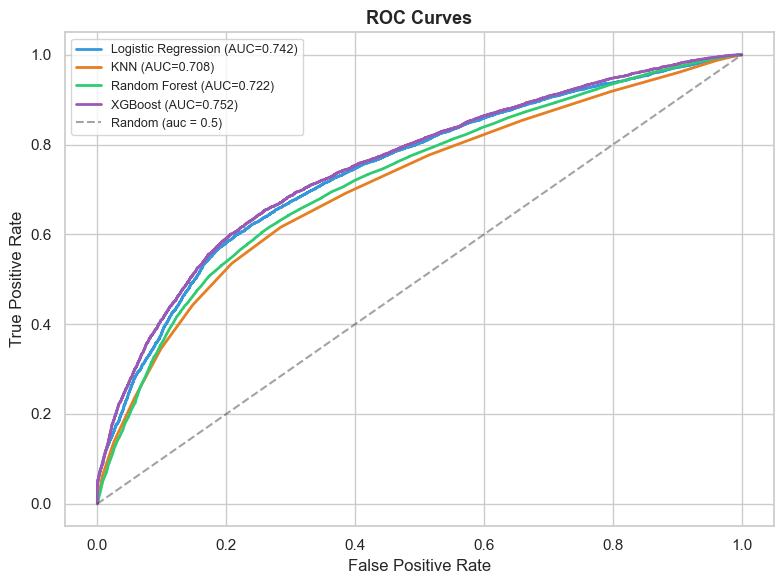

In [12]:
# ── ROC  ────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

for (name, pipeline), color in zip(models.items(), palette):
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random (auc = 0.5)')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)

baseline_ap = y_test.mean()

plt.tight_layout()
plt.show()

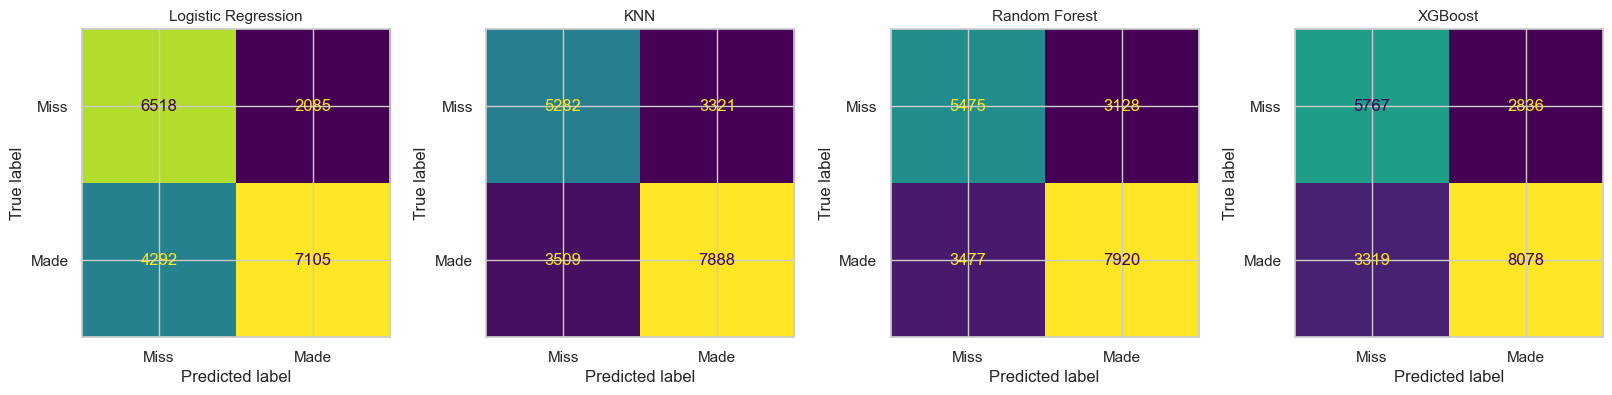

In [13]:
# ── Confusion Matrices ────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred = pipeline.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False,
        display_labels=['Miss', 'Made']
    )
    ax.set_title(name, fontsize=11)
plt.show()

## 8. Cross-Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name in ['Logistic Regression', 'XGBoost']:
    pipeline = models[name]
    scores = cross_val_score(
        pipeline, X, y,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results.append({
        'Model': name,
        'CV Mean AUC': round(scores.mean(), 4),
        'CV Std':      round(scores.std(), 4),
        'CV Min':      round(scores.min(), 4),
        'CV Max':      round(scores.max(), 4),
    })
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

print()
display(pd.DataFrame(cv_results))

Logistic Regression: 0.7413 ± 0.0017
XGBoost: 0.7496 ± 0.0018



,Model,CV Mean AUC,CV Std,CV Min,CV Max
0,Logistic Regression,0.7413,0.0017,0.7389,0.7430
1,XGBoost,0.7496,0.0018,0.7471,0.7522


- Low CV Std indicates that the models do not overfit and are not very sensitive to different data splits, indicating good stability.
- The average ROC-AUC values approximately 73-75%. The difference between models is about 0.0055, which is not very large and may indicate similar predictive ability of the models.

## 9. Hyperparameter Optimization for XGBoost

In [15]:
param_grid_xgb = {
    'model__n_estimators':     [200, 400],
    'model__max_depth':        [3, 5, 7],
    'model__learning_rate':    [0.03, 0.05, 0.1],
    'model__subsample':        [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_alpha':        [0, 0.1, 0.5],
}

search_xgb = RandomizedSearchCV(
    models['XGBoost'],
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring='neg_log_loss',
    cv=3, verbose=1, n_jobs=-1, random_state=42
)
search_xgb.fit(X_train, y_train)

print('Best params:', search_xgb.best_params_)
print('Best CV Log Loss:', round(-search_xgb.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__subsample': 1.0, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 7, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Best CV Log Loss: 0.5803


In [16]:
# ── Comparison before and after optimization ─────────────────────
best_xgb = search_xgb.best_estimator_

y_proba_base = models['XGBoost'].predict_proba(X_test)[:, 1]
y_proba_opt  = best_xgb.predict_proba(X_test)[:, 1]

y_pred_base = (y_proba_base >= 0.5).astype(int)
y_pred_opt  = (y_proba_opt >= 0.5).astype(int)

comparison = pd.DataFrame([
    {
        'Model': 'XGBoost (baseline)',
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba_base), 4),
        'Log Loss': round(log_loss(y_test, y_proba_base), 4),
        'Brier':    round(brier_score_loss(y_test, y_proba_base), 4),
        'Accuracy': round(np.mean(y_pred_base == y_test), 4),
    },
    {
        'Model': 'XGBoost (optimized)',
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba_opt), 4),
        'Log Loss': round(log_loss(y_test, y_proba_opt), 4),
        'Brier':    round(brier_score_loss(y_test, y_proba_opt), 4),
        'Accuracy': round(np.mean(y_pred_opt == y_test), 4),
    }
])
display(comparison)

,Model,ROC-AUC,Log Loss,Brier,Accuracy
0,XGBoost (baseline),0.7518,0.5784,0.1985,0.6922
1,XGBoost (optimized),0.7543,0.5770,0.1977,0.6946


## 10. Feature Experiments — What to Keep?

Check which features are usefull and which could be dropped

,Experiment,ROC-AUC,vs All features
0,All features,0.7543,0.0000
2,Without score features,0.7543,0.0000
1,"Without LOC_X, LOC_Y",0.7534,-0.0009
5,Without time features,0.7533,-0.0010
7,Without positional features,0.7533,-0.0010
4,Action only,0.7295,-0.0248
3,Without Actions,0.7165,-0.0378
6,Positional only,0.7028,-0.0515


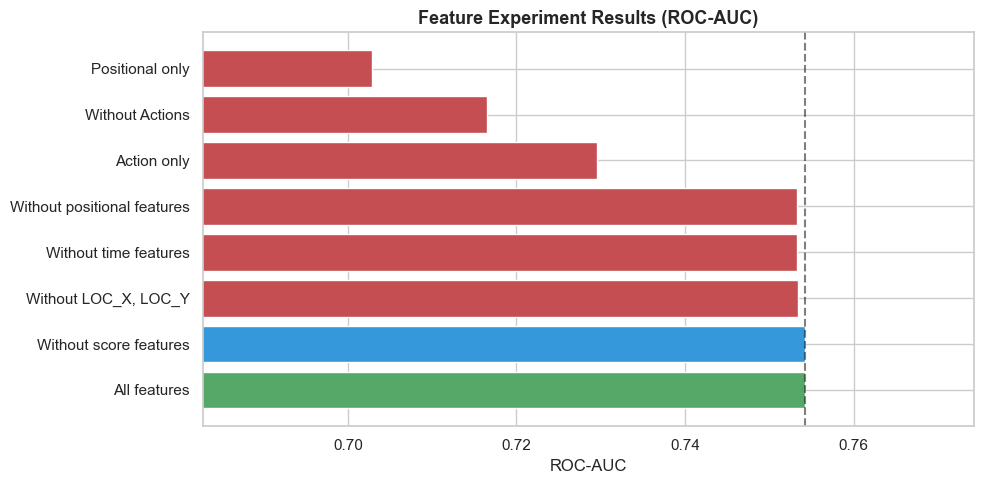

In [17]:
def run_experiment(name, feature_list, num_feats, cat_feats, X_full, y_full):
    """Train XGBoost with given features and return AUC."""
    X_exp = X_full[feature_list].copy()
    Xtr, Xte, ytr, yte = train_test_split(
        X_exp, y_full, test_size=0.2, random_state=42, stratify=y_full
    )
    num_c = Xtr.select_dtypes(include=['int64','float64','int16','bool']).columns
    cat_c = Xtr.select_dtypes(include=['object']).columns
    prep = ColumnTransformer([
        ('num', StandardScaler(), num_c),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_c)
    ])
    pipe = Pipeline([
        ('preprocessor', prep),
        ('model', XGBClassifier(
            **{k.replace('model__',''):v
               for k,v in search_xgb.best_params_.items()},
            random_state=42, eval_metric='logloss', n_jobs=-1
        ))
    ])
    pipe.fit(Xtr, ytr)
    auc_score = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
    return round(auc_score, 4)

experiments = {}

# All features
experiments['All features'] = run_experiment(
    'All', all_features, numerical_features, categorical_features,
    df_model[all_features], y
)

# Without LOC_X, LOC_Y
feats_no_loc = [f for f in all_features if f not in ['LOC_X','LOC_Y']]
experiments['Without LOC_X, LOC_Y'] = run_experiment(
    'no_loc', feats_no_loc, [], [],
    df_model[feats_no_loc], y
)

# Without score-признаков
score_cols = ['scoreMarginBeforeShot','scoreHomeBeforeShot','scoreAwayBeforeShot']
feats_no_score = [f for f in all_features if f not in score_cols]
experiments['Without score features'] = run_experiment(
    'no_score', feats_no_score, [], [],
    df_model[feats_no_score], y
)

# Without Actions
action_cols = ['ACTION_TYPE','MAIN_ACTION_TYPE','OPPONENT_INTERFERED']
feats_no_action = [f for f in all_features
                   if f not in action_cols]
experiments['Without Actions'] = run_experiment(
    'no_action', feats_no_action, [], [],
    df_model[feats_no_action], y
)


# ACTION_TYPE only
action_feats = [f for f in action_cols if f in df_model.columns]
experiments['Action only'] = run_experiment(
    'pos', action_cols, [], [],
    df_model[action_cols], y
)


# Without Time features
time_cols = ['TimeRemainingInPeriod','PERIOD_x', 'OvertimeNumber','IsOvertime', 'IsClutchTime']
feats_no_time = [f for f in all_features
                   if f not in time_cols]
experiments['Without time features'] = run_experiment(
    'no_action', feats_no_time, [], [],
    df_model[feats_no_time], y
)

# Positional only
pos_feats = ['SHOT_DISTANCE','LOC_X','LOC_Y','ANGLE_SIN','ANGLE_COS', 'ANGLE',
             'SHOT_TYPE','SHOT_ZONE_RANGE','SHOT_ZONE_BASIC','SHOT_ZONE_AREA', 
             'ANGLE_SECTOR', 'ABS_ANGLE',]
pos_feats = [f for f in pos_feats if f in df_model.columns]
experiments['Positional only'] = run_experiment(
    'pos', pos_feats, [], [],
    df_model[pos_feats], y
)

# Without Positional features
feats_no_positional = [f for f in all_features
                   if f not in time_cols]
experiments['Without positional features'] = run_experiment(
    'no_action', feats_no_positional, [], [],
    df_model[feats_no_positional], y
)

# ── Results ────────────────────────────────────────────
exp_df = pd.DataFrame([
    {'Experiment': k, 'ROC-AUC': v,
     'vs All features': round(v - experiments['All features'], 4)}
    for k, v in experiments.items()
]).sort_values('ROC-AUC', ascending=False)

display(exp_df)

fig, ax = plt.subplots(figsize=(10, 5))
colors_exp = ['g' if i == 0 else
              ('r' if v < experiments['All features'] else '#3498DB')
              for i, v in enumerate(exp_df['ROC-AUC'])]
ax.barh(exp_df['Experiment'], exp_df['ROC-AUC'], color=colors_exp)
ax.set_xlim(exp_df['ROC-AUC'].min() - 0.02, exp_df['ROC-AUC'].max() + 0.02)
ax.axvline(experiments['All features'], color='black', linestyle='--', alpha=0.5)
ax.set_title('Feature Experiment Results (ROC-AUC)', fontsize=13, fontweight='bold')
ax.set_xlabel('ROC-AUC')
plt.tight_layout()
plt.show()

- Removing score-related features has virtually no effect on the ROC-AUC, indicating that these features are not critical to the model.

- Removing LOC_X and LOC_Y also has virtually no impact on performance, but made it a bit higher.

- Removing time and positional features also slightly impacts the ROC-AUC, with a decrease of approximately -0.0012, indicating that their role is more than score-related features has but not critical.

- Removing ACTION_TYPE significantly degrades the model (-0.0413), indicating that this feature is important for model performance, but using only ACTION_TYPE also significantly reduces the result, suggesting the need to combine features to achieve good results.

## 11. Feature Importance & SHAP

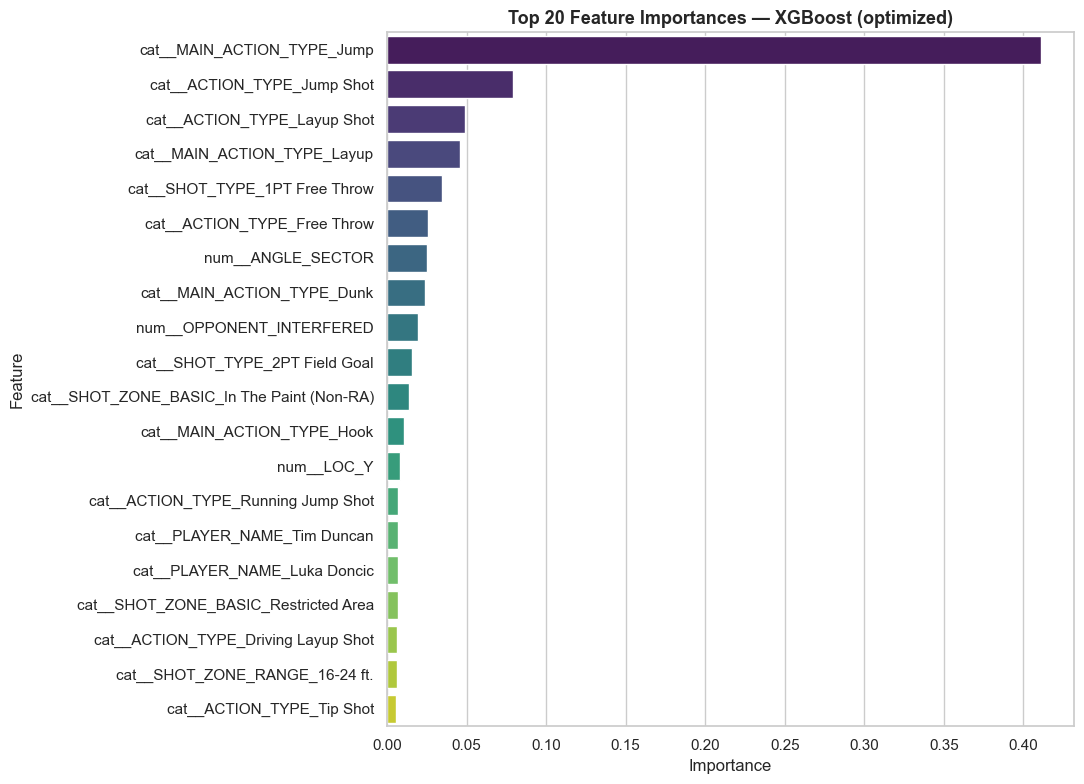

In [18]:
xgb_model = best_xgb.named_steps['model']
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(
    data=importance_df.head(20),
    x='Importance', y='Feature', hue='Feature',
    palette='viridis', ax=ax
)
ax.set_title('Top 20 Feature Importances — XGBoost (optimized)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

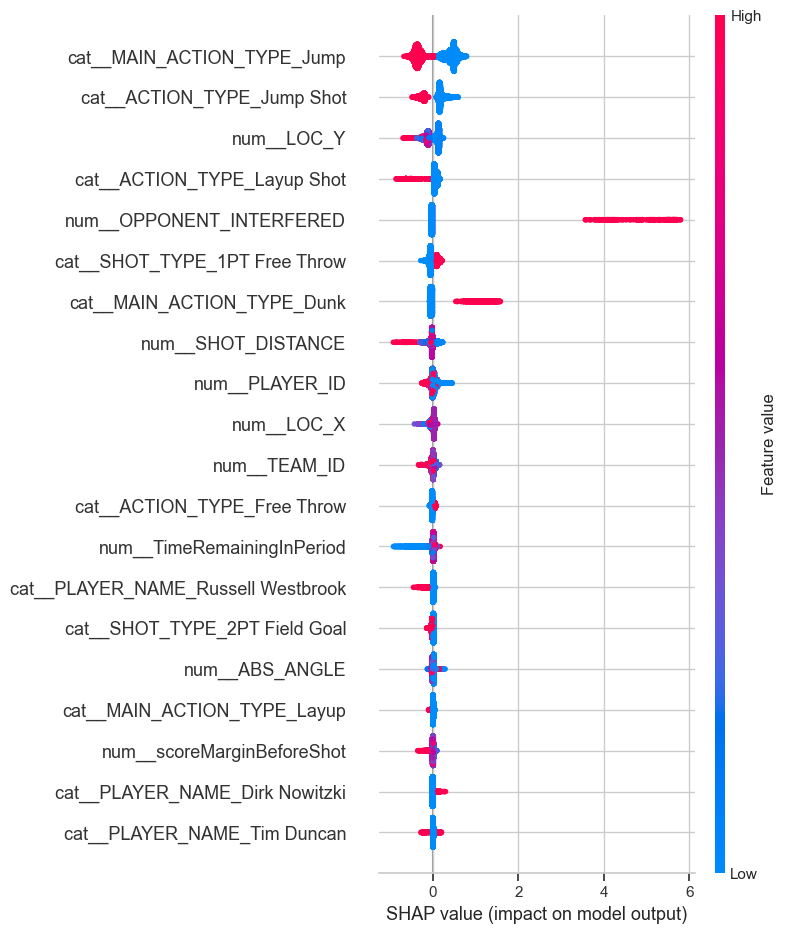

In [19]:
import shap

X_transformed = best_xgb.named_steps['preprocessor'].transform(X_test)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(
    shap_values, X_transformed,
    feature_names=feature_names,
    max_display=20
)

## 12. Calibration Curve

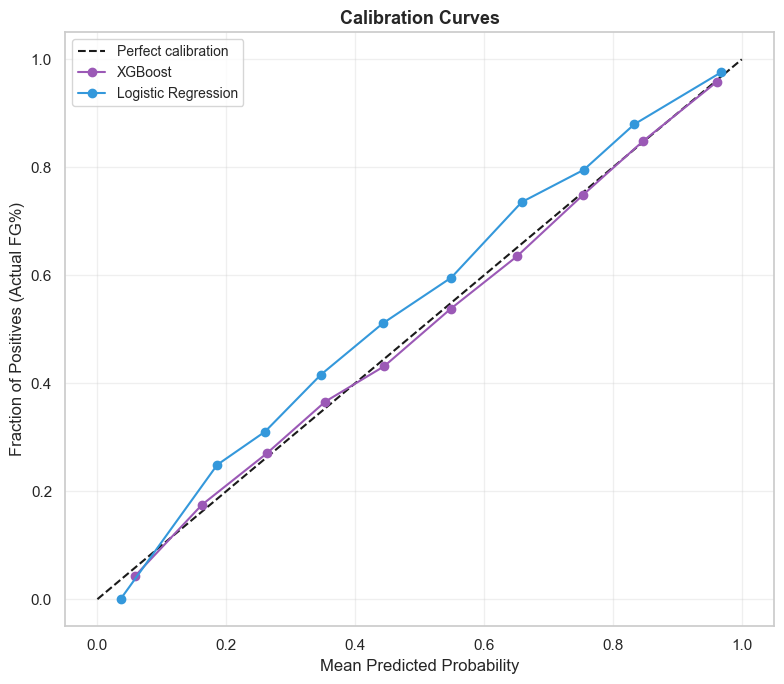

We can see that XGBoost model is good calibrated


In [20]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')

models_to_plot = {
    'XGBoost': models['XGBoost'],
    'Logistic Regression': models['Logistic Regression']
}

palette = ['#9B59B6', '#3498DB']
for (name, pipeline), color in zip(models_to_plot.items(), palette):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
    ax.plot(mean_pred, fraction_pos, marker='o', color=color, label=name)

ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual FG%)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('We can see that XGBoost model is good calibrated')

## 13. Per-Player Prediction Analysis

,PLAYER_NAME,Actual_FG,Expected_FG,Shot_Count,Delta_%
5,Giannis Antetokounmpo,0.607226,0.625782,858,-1.86
0,Anthony Davis,0.606771,0.623035,768,-1.63
8,Kevin Durant,0.607338,0.612165,1281,-0.48
4,Dwyane Wade,0.571555,0.594582,1132,-2.30
14,Nikola Jokic,0.628731,0.593624,536,3.51
7,Kawhi Leonard,0.585843,0.587862,664,-0.20
6,James Harden,0.595122,0.584709,1230,1.04
11,LeBron James,0.573838,0.583325,1957,-0.95
15,Pau Gasol,0.567956,0.567119,905,0.08
18,Tim Duncan,0.558537,0.563786,1230,-0.52


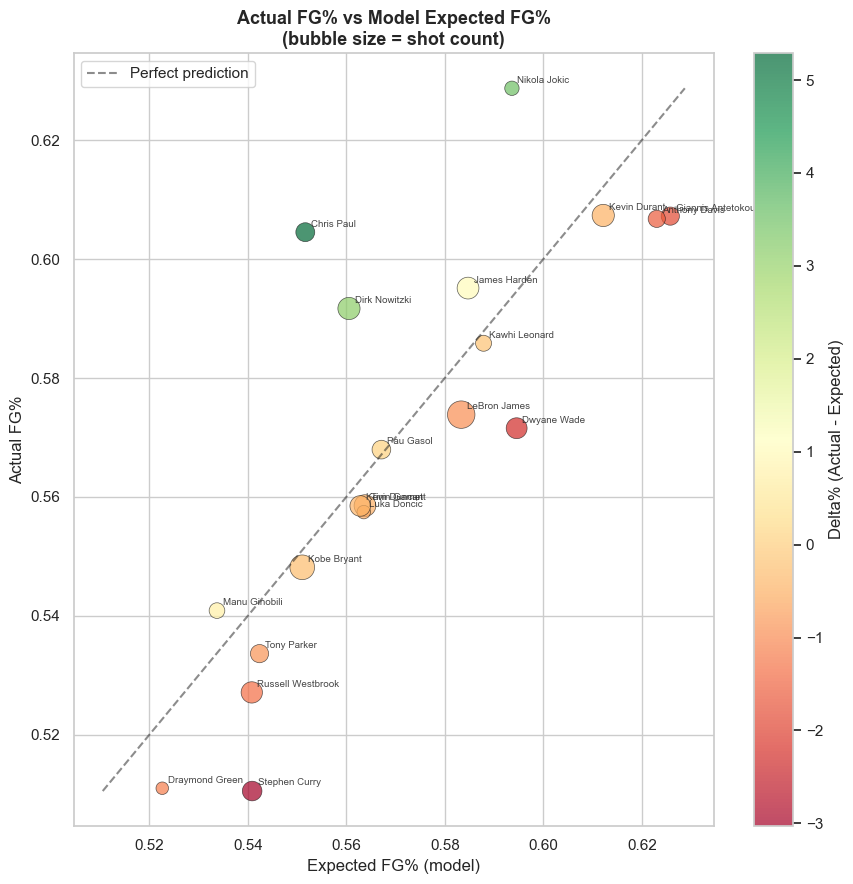

In [21]:
player_df = X_test.copy()
player_df['Actual']    = y_test.values
player_df['Predicted'] = best_xgb.predict_proba(X_test)[:, 1]

player_analysis = player_df.groupby('PLAYER_NAME').agg(
    Actual_FG    = ('Actual',    'mean'),
    Expected_FG  = ('Predicted', 'mean'),
    Shot_Count   = ('Actual',    'count')
).reset_index()
player_analysis['Delta_%'] = (
    (player_analysis['Actual_FG'] - player_analysis['Expected_FG']) * 100
).round(2)
player_analysis = player_analysis.sort_values('Expected_FG', ascending=False)

display(player_analysis)

# ── Scatter: Actual vs Expected ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
scatter = ax.scatter(
    player_analysis['Expected_FG'],
    player_analysis['Actual_FG'],
    s=player_analysis['Shot_Count'] / 5,
    alpha=0.7, c=player_analysis['Delta_%'],
    cmap='RdYlGn', edgecolors='k', linewidths=0.5
)
mn = min(player_analysis[['Expected_FG','Actual_FG']].min())
mx = max(player_analysis[['Expected_FG','Actual_FG']].max())
ax.plot([mn,mx],[mn,mx],'k--', alpha=0.5, label='Perfect prediction')
for _, row in player_analysis.iterrows():
    ax.annotate(row['PLAYER_NAME'],
                (row['Expected_FG'], row['Actual_FG']),
                fontsize=7, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')
plt.colorbar(scatter, ax=ax, label='Delta% (Actual - Expected)')
ax.set_title('Actual FG% vs Model Expected FG%\n(bubble size = shot count)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Expected FG% (model)')
ax.set_ylabel('Actual FG%')
ax.legend()
plt.tight_layout()
plt.show()

## 14. 📋 Summary — All Experiments

In [22]:
all_results = []

# Baseline models
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    all_results.append({
        'Stage': 'Baseline',
        'Model': name,
        'Features': 'All',
        'ROC-AUC':  round(roc_auc_score(y_test, y_proba), 4),
        'Log Loss': round(log_loss(y_test, y_proba), 4),
        'Brier':    round(brier_score_loss(y_test, y_proba), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    })

# Optimized XGBoost
y_proba_opt = best_xgb.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)
all_results.append({
    'Stage': 'Optimized',
    'Model': 'XGBoost',
    'Features': 'All',
    'ROC-AUC':  round(roc_auc_score(y_test, y_proba_opt), 4),
    'Log Loss': round(log_loss(y_test, y_proba_opt), 4),
    'Brier':    round(brier_score_loss(y_test, y_proba_opt), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
})

final_df = pd.DataFrame(all_results).sort_values(['Stage','ROC-AUC'], ascending=[True, False])
display(final_df)
best_row = final_df.loc[final_df['ROC-AUC'].idxmax()]
print(f'Best model: {best_row["Model"]} ({best_row["Stage"]}) — AUC = {best_row["ROC-AUC"]}')

,Stage,Model,Features,ROC-AUC,Log Loss,Brier,Accuracy
3,Baseline,XGBoost,All,0.7518,0.5784,0.1985,0.6923
0,Baseline,Logistic Regression,All,0.7424,0.5940,0.2049,0.6812
2,Baseline,Random Forest,All,0.7221,0.6481,0.2111,0.6697
1,Baseline,KNN,All,0.7084,0.7368,0.2164,0.6585
4,Optimized,XGBoost,All,0.7543,0.5770,0.1977,0.6923


Best model: XGBoost (Optimized) — AUC = 0.7543


## 15. 🏀 Analysis by Shot Type (1PT, 2PT, 3PT)

AUC by Shot Type per Model:


Shot Type,1PT Free Throw,2PT Field Goal,3PT Field Goal
Model,,,
KNN,0.5531,0.6459,0.5583
Logistic Regression,0.5677,0.7024,0.5722
Random Forest,0.5298,0.6936,0.5679
XGBoost,0.6085,0.7157,0.5842


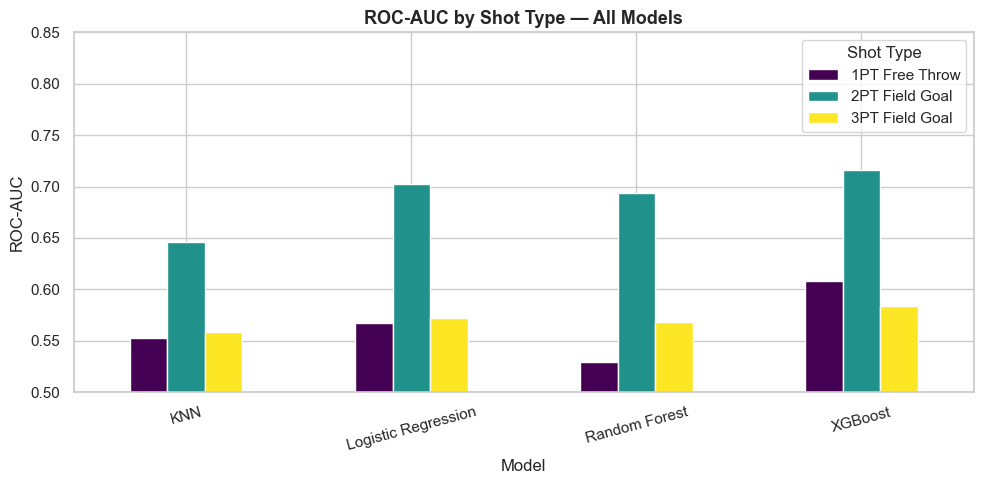

In [23]:
# ── AUC by shot_type ─────────────────
shot_model_results = []
for shot_type in player_df['SHOT_TYPE'].unique():
    mask    = (X_test['SHOT_TYPE'] == shot_type)
    X_sub   = X_test[mask]
    y_sub   = y_test[mask]
    if y_sub.nunique() < 2 or len(y_sub) < 30:
        continue
    for name, pipeline in models.items():
        yp = pipeline.predict_proba(X_sub)[:, 1]
        shot_model_results.append({
            'Shot Type': shot_type,
            'Model':     name,
            'ROC-AUC':   round(roc_auc_score(y_sub, yp), 4),
            'N shots':   len(y_sub)
        })

sm_df = pd.DataFrame(shot_model_results)
pivot = sm_df.pivot(index='Model', columns='Shot Type', values='ROC-AUC')
print('AUC by Shot Type per Model:')
display(pivot)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, edgecolor='white', colormap='viridis')
ax.set_title('ROC-AUC by Shot Type — All Models', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 0.85)
ax.legend(title='Shot Type')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 16. ⏱️ Analysis by Game Situation

Checking how the model can predict the pressure

,Situation,Model,N,Actual FG%,ROC-AUC,Log Loss
0,Clutch,XGBoost,1210,56.8,0.7693,0.5676
1,Clutch,XGBoost opt,1210,56.8,0.7689,0.5675
2,Clutch,Log Reg,1210,56.8,0.7629,0.5771
3,Regular,XGBoost,18790,57.0,0.7505,0.5791
4,Regular,XGBoost opt,18790,57.0,0.7532,0.5776
5,Regular,Log Reg,18790,57.0,0.7409,0.5950
6,Playoffs,XGBoost,2737,56.9,0.7500,0.5799
7,Playoffs,XGBoost opt,2737,56.9,0.7523,0.5789
8,Playoffs,Log Reg,2737,56.9,0.7358,0.6025
9,RegSeason,XGBoost,17263,57.0,0.7520,0.5781


Overall AUC = 0.7543105067374334


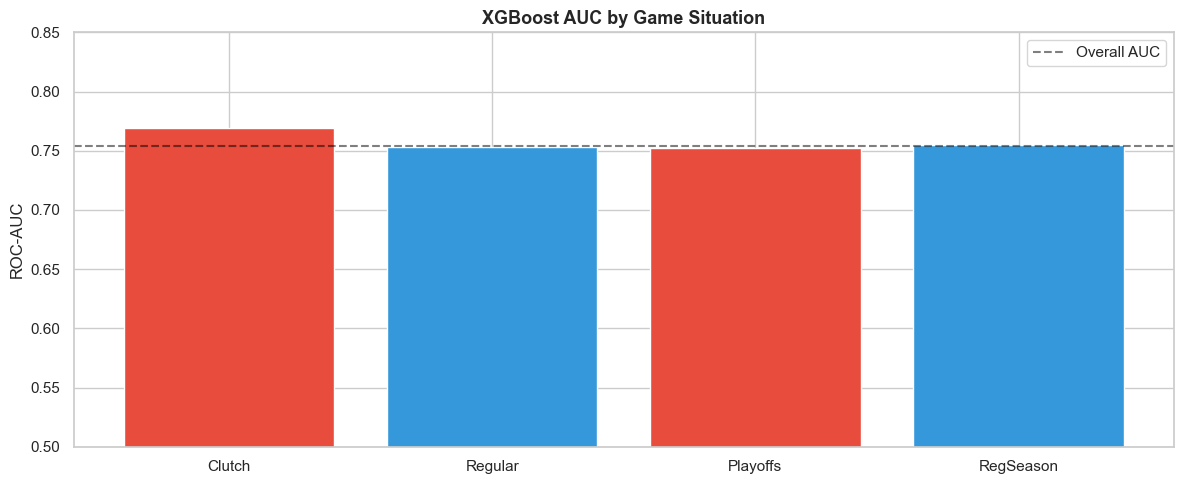

In [25]:
situations = [
    ('Clutch',    'IsClutchTime', True),
    ('Regular',   'IsClutchTime', False),
    ('Playoffs',  'is_playoffs',  True),
    ('RegSeason', 'is_playoffs',  False),
]

sit_results = []
for sit_name, col, val in situations:
    if col not in X_test.columns:
        continue
    mask  = (X_test[col] == val)
    X_sub = X_test[mask]
    y_sub = y_test[mask]
    if y_sub.nunique() < 2 or len(y_sub) < 30:
        continue
    for name, pipeline in [('XGBoost', models['XGBoost']),
                            ('XGBoost opt', best_xgb),
                            ('Log Reg', models['Logistic Regression'])]:
        yp = pipeline.predict_proba(X_sub)[:, 1]
        sit_results.append({
            'Situation': sit_name,
            'Model':     name,
            'N':         len(y_sub),
            'Actual FG%': round(y_sub.mean() * 100, 1),
            'ROC-AUC':   round(roc_auc_score(y_sub, yp), 4),
            'Log Loss':  round(log_loss(y_sub, yp), 4),
        })

sit_df = pd.DataFrame(sit_results)
display(sit_df)

# ── Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
pivot_sit = sit_df[sit_df['Model']=='XGBoost opt'].set_index('Situation')['ROC-AUC']
colors_sit = ['#E74C3C' if 'Clutch' in s or 'Playoff' in s else '#3498DB'
              for s in pivot_sit.index]
ax.bar(pivot_sit.index, pivot_sit.values, color=colors_sit, edgecolor='white')
ax.axhline(roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]),
           color='black', linestyle='--', alpha=0.5, label='Overall AUC')
ax.set_ylim(0.5, 0.85)
ax.set_title('XGBoost AUC by Game Situation', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.legend()
plt.tight_layout()
print(f'Overall AUC = {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])}')
plt.show()

## 17. Final Findings and Conclusions

### Data Leakage

* `pointsHome`, `pointsAway`, `points`, and `scoreMargin` were confirmed as leakage features because they are known only AFTER the shot outcome
* Correlation analysis showed moderate correlations with the target (`~0.49–0.52`), confirming leakage
* These variables were removed from the final dataset ✅
* `scoreHomeBeforeShot`, `scoreAwayBeforeShot`, and `scoreMarginBeforeShot` are safe because they describe the game state BEFORE the shot

### Multicollinearity

* Strong multicollinearity was detected between several temporal and score-related variables:

  * `TimeRemainingInGame` ↔ `PERIOD_x` correlation ≈ `-0.967`
  * `TotalPlayedTime` ↔ `PERIOD_x` correlation ≈ `-0.97`
  * `scoreHomeBeforeShot` ↔ `scoreAwayBeforeShot` correlation ≈ `0.87`
* Removing redundant variables caused almost no performance degradation

### Model Performance

* Best models achieved ROC-AUC values around `0.72-0.75`
* This is considered a strong result for basketball shot prediction tasks, where substantial randomness exists
* XGBoost slightly outperformed Logistic Regression:

  * indicates the presence of nonlinear relationships
  * especially interactions between shot location, action type and game situation
* Logistic Regression remained highly competitive, suggesting that a large part of shot prediction can still be captured through relatively simple decision boundaries
* Random Forest shown good results, but not so high in comparison to the two mentioned above
* KNN consistently produced the weakest results

### Probability Estimation

* XGBoost achieved the best calibrated probabilities overall
* Calibration curves showed that predictions remain reasonably aligned with observed shot success frequencies

### Feature Importance

* The most influential features were:

  * `SHOT_DISTANCE`
  * `LOC_Y`
  * `ABS_ANGLE` / `ANGLE_COS`
  * `ANGLE_SECTOR`
  * `TimeRemainingInPeriod`
  * `MAIN_ACTION_TYPE`
    
* Location information consistently dominated prediction quality
* Action type significantly improved performance because it captures shot difficulty and play context
* Score-related features had relatively weak importance, suggesting that spatial shot quality matters more than current score situation

### Shot Type Analysis

* The model performed differently on 1PT, 2PT and 3PT attempts
* 2-point shots were generally easier to predict due to:

  * shorter distance
  * more structured shot patterns
  * lower variance
* 3-point shots showed greater uncertainty and variability
* 1-point shots is something between 3 and 2 PT shots

### Game Situation Analysis

* Prediction quality slightly decreased during playoff games but improved during clutch situations.
* This suggests that different types of game pressure affect shot behavior differently
* These results indicate that contextual and psychological factors influence shot outcomes, although they are only partially represented in the available data

### Expected vs Actual Performance

* Comparing actual FG% with model-estimated expected FG% revealed differences in player shot efficiency
* Some players consistently outperformed model expectations, indicating:

  * superior shot-making ability
  * difficult shot conversion
  * better shot selection
* Other players underperformed relative to expected shot quality

### Final Feature Set

#### Kept Features

* `SHOT_DISTANCE`
* `LOC_Y`
* `ANGLE_SIN`
* `ANGLE_COS`
* `ANGLE_SECTOR`
* `ABS_ANGLE`
* `TimeRemainingInPeriod`
* `OvertimeNumber`
* `PERIOD_x`
* `scoreMarginBeforeShot`
* `ACTION_TYPE`
* `MAIN_ACTION_TYPE`
* `SHOT_TYPE`
* `SHOT_ZONE_RANGE`
* `SHOT_ZONE_BASIC`
* `SHOT_ZONE_AREA`
* `PLAYER_NAME`
* `IsClutchTime`
* `is_playoffs`
* `IsOvertime`
* `IS_HOME`
* `OPPONENT_INTERFERED`

#### Removed Features

* `pointsHome`, `pointsAway`, `points`, `scoreMargin` → leakage
* `scoreHomeBeforeShot`, `scoreAwayBeforeShot` → redundant with score margin
* `TimeRemainingInGame` (we have `PERIOD_x`) → highly collinear

### Overall Conclusion

* Basketball shot prediction remains inherently probabilistic and partially random
* Maybe it would be better when we know such variables such as:
  * defensive pressure
  * pass quality
  * fatigue
  * player rhythm
  * psychological state
* Nevertheless, the developed models successfully learned meaningful spatial and contextual shooting patterns